# Random keys without surprises

CPU companion; no accelerator is required. TPU execution not validated.

- Treat a key as an explicit input
- Carry the continuation key explicitly
- Separate replay from a statistical claim
- Allocate randomness by sample identity

You saved the seed, yet your simulation repeats exactly the same noise at every step. Let’s follow the random key. In JAX, using a key again repeats the same draw; splitting it gives you keys for separate draws. We’ll practice both deliberate replay and fresh sampling before adding randomness to a training loop.

## The idea

A random sampler in JAX receives an explicit key. Reusing the same key with the same sampler repeats the same computation. Splitting gives us separately owned keys, so the program can show which operation receives which randomness.

## A key is an input, not a moving cursor

Imagine a training step that needs dropout randomness and a key for the next step. Split the incoming key, use one child for dropout, and return the other as the continuation key. The drawing should branch once; it should not show a sampler secretly advancing the parent key.

If two augmentation calls receive the same key and otherwise identical inputs, they can produce the same augmentation. Different variable names do not make the underlying key values different. This is a data-flow bug that ordinary shape checks will miss.

For recovery, save the continuation key at the same boundary as model and data position. Reconstructing an initial seed and restarting the random stream is not equivalent to restoring the next key after many training steps.

### Pause and reason

Does calling a sampler consume or mutate the key variable?

<details><summary>Compare your reasoning</summary>

No. The key is an explicit value. Your program must choose new child keys and carry the next key forward; otherwise repeated calls can replay the same sample.

</details>

## Treat a key as an explicit input

A JAX random operation is deterministic given its key and other arguments. The key is not a mutable generator that automatically advances after a call. Calling normal twice with the same key, shape and dtype reproduces the draw. That property is useful for replay and dangerous when accidental reuse makes samples correlated.

A seed is only the initial description of an experiment. Splitting describes where subsequent random choices come from. Write down which function owns the continuation key and which subkey is consumed by a draw. Do not pass one subkey to two independent components.

```text
seed → root key
root key --split--> continuation key + sample key
sample key --normal(shape=(3,))--> one sample
```

## Carry the continuation key explicitly

In the worked program, `key, sample_key = split(key)` replaces the variable key with a continuation value. The old key was not mutated; Python rebound a name. sample_key belongs to the immediate draw. The next split uses the retained continuation, not sample_key.

This convention gives each training or simulation step a small state transition: receive key → split → sample → return next key. Later, checkpoints need to store that next key alongside model and optimizer state. Storing parameters alone cannot reproduce the next random batch.

## Separate replay from a statistical claim

For this fixed seed, fresh subkeys produce visibly different draws. That observation is not proof of statistical independence, and different random draws can theoretically coincide. Equality of a single pair is therefore not a general test of randomness quality.

The reliable replay test is to reconstruct the same program from the same seed and compare its results. A change to key allocation can alter all later samples. Do not promise identical streams across arbitrary JAX versions, PRNG implementations, shapes or devices.

## Allocate randomness by sample identity

Splitting a root into four keys is useful for one fixed batch. If the batch membership changes, assignment by position may associate a different draw with a particular sample. fold_in lets you combine a stable integer identity with a base key, which can make per-example randomness stable under reordering.

Keep identifiers unique where distinct randomness is intended. Reusing an identifier repeats its derived key. This is deterministic bookkeeping, not a security primitive or a substitute for recording the PRNG implementation.

## Prepare the inputs

Create main.py in your lesson workspace. Add this first block; use the environment from setup.

In [1]:
import jax
import jax.numpy as jnp

These explicit inputs define the case that the later checks will verify.

## Build the computation

Append this block below the inputs in the same file.

In [2]:
key = jax.random.key(42)
key, sample_key = jax.random.split(key)
a = jax.random.normal(sample_key, (3,))
repeated = jax.random.normal(sample_key, (3,))
key, next_key = jax.random.split(key)
b = jax.random.normal(next_key, (3,))

random.split returns two new keys. noise_step returns the continuation key as part of its result so the caller can use fresh noise on the next transition.

## Run and check the result

Append the checks, save main.py, and run python main.py from this folder using your course environment.

In [3]:
print("Replay equal:", bool(jnp.array_equal(a, repeated)))
print("Fresh draw equal:", bool(jnp.array_equal(a, b)))
assert jnp.array_equal(a, repeated)
assert not jnp.array_equal(a, b)

Replay equal: True
Fresh draw equal: False


Compare the output to the expected result below before making the exercise change.

## Run the example

In [4]:
import jax
import jax.numpy as jnp
key = jax.random.key(42)
key, sample_key = jax.random.split(key)
a = jax.random.normal(sample_key, (3,))
repeated = jax.random.normal(sample_key, (3,))
key, next_key = jax.random.split(key)
b = jax.random.normal(next_key, (3,))
print("Replay equal:", bool(jnp.array_equal(a, repeated)))
print("Fresh draw equal:", bool(jnp.array_equal(a, b)))
assert jnp.array_equal(a, repeated)
assert not jnp.array_equal(a, b)

Replay equal: True
Fresh draw equal: False


Expected: Replay equal: True; Fresh draw equal: False.

## Reused keys replay the same sample

Predict: Will a repeated draw lie on top of the original?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [5]:
visual_data = {'kind': 'line', 'x': [0, 1, 2], 'xlabel': 'sample coordinate', 'ylabel': 'normal draw', 'series': [{'label': 'first draw', 'y': a.tolist()}, {'label': 'same key replay', 'y': repeated.tolist()}, {'label': 'split next draw', 'y': b.tolist()}]}

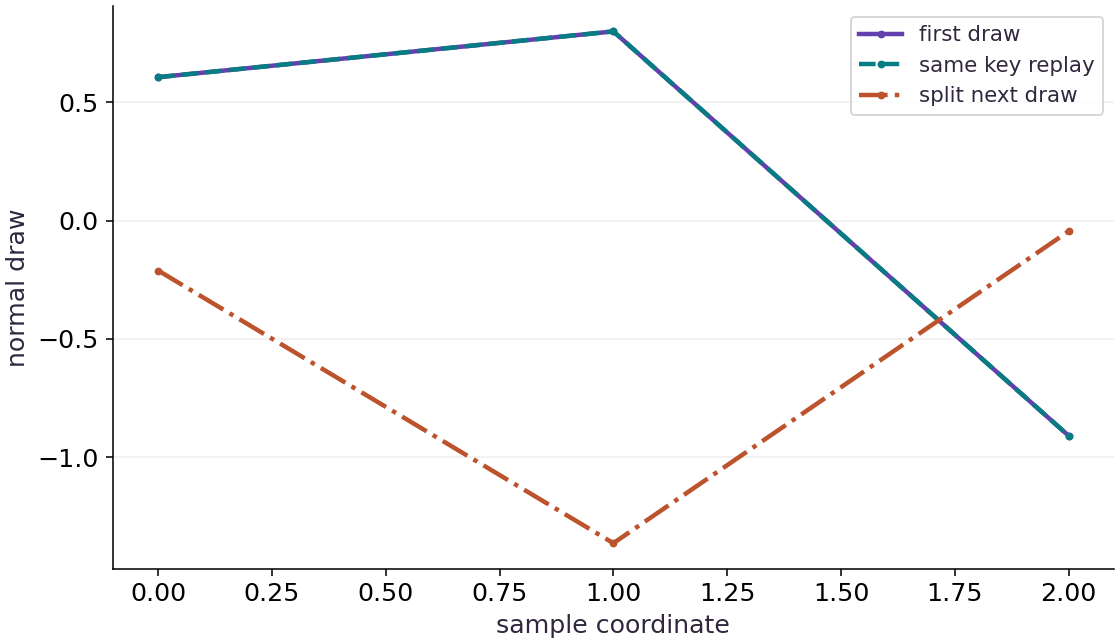

In [6]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data.get('scale') == 'probability' or data['unit'] in ('attention weight', 'next-token probability', 'masked-token probability'):
            kw.update(vmin=0, vmax=1)
        categorical = data.get('scale') == 'categorical' or any(name in data['unit'] for name in ('device ID','program ID'))
        if categorical:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            from matplotlib import colormaps
            ids=np.unique(a).astype(int)
            boundaries=np.r_[ids[0]-.5,(ids[:-1]+ids[1:])/2,ids[-1]+.5]
            kw.update(cmap=ListedColormap([colormaps['tab20'](i) for i in range(len(ids))]), norm=BoundaryNorm(boundaries,len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if categorical else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


def draw_mechanism(ax, diagram):
    """Draw a source-authored conceptual/analytic mechanism, never measured data."""
    import numpy as np
    from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Ellipse
    panel = diagram['panel']
    kind = panel['kind']
    colors = {'data':('#eef3ff','#3559a8'), 'state':('#f0eafa','#6240ad'),
              'fixed':('#f1f3f5','#536273'), 'result':('#e5f4ee','#17735c'),
              'warning':('#fff0e6','#a64d20')}
    if kind == 'graph':
        ax.set(xlim=(0,panel.get('width',10)),ylim=(panel.get('height',8),0))
        ax.axis('off')
        nodes={node['id']:node for node in panel['nodes']}
        for edge in panel['edges']:
            a,b=nodes[edge['from']],nodes[edge['to']]
            side_a=edge.get('exit','bottom'); side_b=edge.get('enter','top')
            def port(node,side):
                x,y=node['x'],node['y']; w,h=node.get('w',3),node.get('h',.8)
                return {'top':(x,y-h/2),'bottom':(x,y+h/2),'left':(x-w/2,y),'right':(x+w/2,y)}[side]
            start,end=port(a,side_a),port(b,side_b)
            ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'-|>','color':'#536273','lw':1.7,'connectionstyle':edge.get('curve','arc3,rad=0')},zorder=1)
            if edge.get('label'):
                tx,ty=edge.get('labelAt',((start[0]+end[0])/2,(start[1]+end[1])/2))
                ax.text(tx,ty,edge['label'],ha='center',va='center',fontsize=10,color='#394658',bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=4)
        for node in panel['nodes']:
            fill,stroke=colors[node.get('tone','data')]
            x,y=node['x'],node['y'];w,h=node.get('w',3),node.get('h',.8)
            ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.02,rounding_size=0.07',facecolor=fill,edgecolor=stroke,lw=1.5,zorder=2))
            ax.text(x,y,node['label'],ha='center',va='center',fontsize=node.get('fontSize',12),color='#172334',zorder=3)
    elif kind == 'table':
        ax.axis('off')
        table=ax.table(cellText=panel['rows'],colLabels=panel['headers'],cellLoc='center',loc='center',colWidths=panel.get('widths'))
        table.auto_set_font_size(False);table.set_fontsize(12);table.scale(1,2.7)
        for (row,col),cell in table.get_celld().items():
            cell.set_edgecolor('#ccd3df')
            cell.set_facecolor('#e9e4f5' if row==0 else ('#f4f7fb' if row%2 else '#ffffff'))
            cell.set_text_props(color='#172334',weight='bold' if row==0 else 'normal')
    elif kind == 'clipping':
        ax.add_patch(Circle((0,0),2.5,fill=False,edgecolor='#17735c',linestyle='--',lw=1.8))
        ax.add_patch(Rectangle((-2.5,-2.5),5,5,fill=False,edgecolor='#a64d20',linestyle=':',lw=1.8))
        for end,color,label,offset in [((3,4),'#3559a8','Original (3, 4)',(8,5)),((1.5,2),'#17735c','Norm clip (1.5, 2)',(-126,-16)),((2.5,2.5),'#a64d20','Coordinate clip (2.5, 2.5)',(8,-2))]:
            ax.annotate('',xy=end,xytext=(0,0),arrowprops={'arrowstyle':'-|>','color':color,'lw':2.6})
            ax.annotate(label,end,xytext=offset,textcoords='offset points',color=color,fontsize=11)
        ax.set(xlim=(-3,5.8),ylim=(-3,4.8),xlabel='gradient coordinate 1',ylabel='gradient coordinate 2')
        ax.set_aspect('equal');ax.grid(alpha=.15)
    elif kind == 'patches':
        ax.set(xlim=(-.1,4.1),ylim=(4.1,-.1));ax.set_aspect('equal');ax.axis('off')
        for i in range(4):
            x,y=(i%2)*2,(i//2)*2
            visible=i in [0,3]
            ax.add_patch(Rectangle((x,y),2,2,facecolor='#e5f4ee' if visible else '#fff0e6',edgecolor='#17735c' if visible else '#a64d20',hatch=None if visible else '///',lw=2))
            ax.text(x+1,y+1,f'Patch {i}\n'+('visible input' if visible else 'hidden target'),ha='center',va='center',fontsize=14,bbox={'facecolor':'white','edgecolor':'none','alpha':.94,'pad':5})
        for a in [1,3]:
            ax.axhline(a,color='#172334',alpha=.25,lw=.7);ax.axvline(a,color='#172334',alpha=.25,lw=.7)
    elif kind == 'receptive-field':
        ax.set(xlim=(-.15,5.15),ylim=(5.15,-.15));ax.set_aspect('equal');ax.axis('off')
        for row in range(5):
            for col in range(5):
                selected=1<=row<=3 and 1<=col<=3
                ax.add_patch(Rectangle((col,row),1,1,facecolor='#e9e4f5' if selected else '#f4f7fb',edgecolor='#a6afc1',lw=1))
                ax.text(col+.5,row+.5,f'{row},{col}',ha='center',va='center',fontsize=12)
        ax.add_patch(Rectangle((1,1),3,3,fill=False,edgecolor='#6240ad',lw=3))
        ax.set_title('One 3 × 3 receptive field inside a 5 × 5 input',fontsize=13,pad=12)
    elif kind == 'covariance':
        for covariance,color,label in [(np.array([[1,.8],[.8,1]]),'#6240ad','Correlated covariance'),(np.eye(2),'#17735c','Same marginals, zero covariance')]:
            eig,vec=np.linalg.eigh(covariance);order=np.argsort(eig)[::-1];eig=eig[order];vec=vec[:,order]
            angle=np.degrees(np.arctan2(vec[1,0],vec[0,0]))
            ax.add_patch(Ellipse((0,0),2*np.sqrt(eig[0]),2*np.sqrt(eig[1]),angle=angle,fill=False,lw=2.5,edgecolor=color,label=label))
        ax.set(xlim=(-1.8,1.8),ylim=(-1.8,1.8),xlabel='first variable',ylabel='second variable')
        ax.set_aspect('equal');ax.grid(alpha=.2);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.14),fontsize=10)
    elif kind == 'timeline':
        ax.set(xlim=(0,10),ylim=(-.7,2.7),yticks=[0,1,2],yticklabels=['Host','Device','Measurement'])
        for start,length,y,label,color in [(0,1,0,'dispatch','#3559a8'),(1,6,1,'device work','#6240ad'),(1,6,0,'wait for result','#a64d20'),(0,7,2,'completed-result interval','#17735c')]:
            ax.barh(y,length,left=start,height=.45,color=color,alpha=.18)
            ax.text(start+length/2,y,label,ha='center',va='center',fontsize=11)
        ax.axvline(7,color='#536273',linestyle='--');ax.text(7.1,.5,'result ready',fontsize=11)
        ax.set_xlabel('conceptual order; lengths are not measured durations')
        ax.invert_yaxis()
    else:
        raise ValueError(f'Unknown mechanism kind: {kind}')

panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

The horizontal axis selects a coordinate within a three-element random draw; the vertical axis gives its sampled value. The solid first-draw line and dashed same-key replay line lie on top of each other. The dash-dot line comes from a new split key.

The replay repeats approximately $(0.606,0.799,-0.909)$, while the split-key draw is approximately $(-0.211,-1.363,-0.045)$. Two curves are hard to distinguish precisely because their coordinates are equal.

### Connect it to the computation

A JAX random function is deterministic given the same key and arguments. Calling it again with that key replays the result; it does not silently advance a hidden random state. Splitting produces a new key for a new draw.

The lines only connect coordinates to make equality visible. This is not a time series or a probability density, and three different values cannot establish statistical independence. The practical check is reproducibility: reuse for deliberate replay, split for the next stochastic operation.

## Implement one random state transition

Predict: Predict which part of the return value must be reused for the next draw.

In [7]:
def noise_step(key):
    next_key,draw_key=jax.random.split(key)
    return next_key,jax.random.normal(draw_key,(2,))
root=jax.random.key(9)
k1,n1=noise_step(root)
k2,n2=noise_step(k1)
r1,replay1=noise_step(jax.random.key(9))
r2,replay2=noise_step(r1)
assert jnp.array_equal(n1,replay1) and jnp.array_equal(n2,replay2)
assert jnp.array_equal(jax.random.key_data(k2),jax.random.key_data(r2))

Expected: Reconstructing the two steps reproduces both samples and the continuation key.

Replay compares complete state transitions. It catches lost continuation state, not only a repeated final number.

## Keep identity under reordering

Predict: If examples $3$ and $8$ swap order, should their identity-derived noise swap too?

In [8]:
base=jax.random.key(11)
def by_id(ids):
    return jax.vmap(lambda i:jax.random.normal(jax.random.fold_in(base,i),()))(ids)
forward=by_id(jnp.array([3,8]))
reverse=by_id(jnp.array([8,3]))
assert jnp.array_equal(forward,reverse[::-1])

Expected: Noise follows the identifiers, not their batch positions.

fold_in makes the assignment explicit. Repeated IDs would deliberately reproduce a draw.

## Your exercise

Split a fresh seed into four keys, then use vmap to draw two normal values from each. Replay from the seed and compare.

In [9]:
# Write your attempt here.

## Reference solution

Try your own implementation first.

In [10]:
def draw(seed):
    keys = jax.random.split(jax.random.key(seed), 4)
    return jax.vmap(lambda k: jax.random.normal(k, (2,)))(keys)
assert draw(7).shape == (4, 2)
assert jnp.array_equal(draw(7), draw(7))

## Replay a noisy prediction · Practice

Draw one noise value per example for prediction $2x+1$. Reconstruct the same batch from the seed, then change only $x$.

Hint: Reuse the random construction for a controlled comparison, not accidentally across independent training steps.

In [11]:
# Write your attempt here.

## Reference reasoning

Holding noise fixed isolates the changed numerical input. That is a deliberately coupled experiment.

In [12]:
def noisy_prediction(seed,x):
    eps=jax.random.normal(jax.random.key(seed),x.shape)
    return 2*x+1+eps
inputs=jnp.array([0.,1.,2.])
assert jnp.array_equal(noisy_prediction(4,inputs),noisy_prediction(4,inputs))
assert jnp.allclose(noisy_prediction(4,inputs+1)-noisy_prediction(4,inputs),2.,atol=1e-6)

## Diagnose key reuse in a loop · Challenge

Write the broken loop that draws with one key three times, demonstrate repeated rows, then repair it by threading the continuation.

Hint: The draw function does not mutate the key.

In [13]:
# Write your attempt here.

## Reference reasoning

The repeated-row symptom comes from key allocation. The last inequality checks this fixed demonstration, not every possible random stream.

In [14]:
root=jax.random.key(5)
broken=jnp.stack([jax.random.normal(root,(2,)) for _ in range(3)])
assert jnp.array_equal(broken[0],broken[1])
current=root
rows=[]
for _ in range(3):
    current,noise=noise_step(current)
    rows.append(noise)
fixed=jnp.stack(rows)
assert fixed.shape==(3,2)
assert not jnp.array_equal(fixed[0],fixed[1])

## Checkpoint

What happens if the same key is used twice for the same random operation?

1. The generator automatically advances
2. The same sample is reproduced
3. JAX guarantees an exception

## Diagnose

The repeated-row symptom comes from key allocation. The last inequality checks this fixed demonstration, not every possible random stream.

## Evidence

Keep a key-ownership tree, two-step replay including the final key, the per-ID reorder check, and the broken/repaired repeated-noise loop.

## Carry forward

- Replay compares complete state transitions. It catches lost continuation state, not only a repeated final number.
- fold_in makes the assignment explicit. Repeated IDs would deliberately reproduce a draw.

## Primary references

- [JAX pseudorandom numbers](https://docs.jax.dev/en/latest/101/random.html)